## Multiple Linear regression

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np


In [3]:
df = pd.read_csv('../data/processed/cleaned_googleplaystore.csv')

In [4]:
# preparing the dataset
df["log_reviews"] = np.log1p(df["Reviews"])
df["log_installs"] = np.log1p(df["Installs"])

In [5]:
model_df = df[
    [
        "Rating",
        "log_reviews",
        "log_installs",
        "Size",
        "Price"
    ]
]

In [6]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rating        9659 non-null   float64
 1   log_reviews   9659 non-null   float64
 2   log_installs  9659 non-null   float64
 3   Size          9659 non-null   float64
 4   Price         9659 non-null   float64
dtypes: float64(5)
memory usage: 377.4 KB


In [7]:
# define X and Y
X = model_df[
    [
        "log_reviews",
        "log_installs",
        "Size",
        "Price"
    ]
]

y = model_df["Rating"]

In [8]:
# check dimensions
print(X.shape)
print(y.shape)

(9659, 4)
(9659,)


In [9]:
# Train and split just like simple regression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [11]:
# Train
model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.12,-0.11,-0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['log_reviews','log_installs','Size','Price']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.477
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [12]:
# Examine the coefficient
model.coef_

array([ 0.12464253, -0.10699312, -0.00022385, -0.00092374])

In [13]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,log_reviews,0.124643
1,log_installs,-0.106993
2,Size,-0.000224
3,Price,-0.000924


In [14]:
print("Intercept:", model.intercept_)

Intercept: 4.4771468237607985


In [15]:
# make predictions
y_pred = model.predict(X_test)

In [16]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,4.100000,4.095326
1,4.500000,4.119936
2,4.400000,4.169633
3,4.600000,4.285115
4,3.900000,4.065575
5,4.193338,4.220391
6,4.800000,4.239352
7,4.100000,4.278438
8,5.000000,4.297516
9,3.700000,4.092856


In [17]:
# evaluate the model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [18]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.3239805130520938
MSE : 0.23181355762545594
RMSE: 0.481470204296648
R²  : 0.08498685403498163


In [19]:
# Adjusted R^2
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = (
    1 -
    (1 - r2) *
    (n - 1) /
    (n - p - 1)
)

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 0.08308750137080934


In [20]:
# training VS Test performance
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(
    y_train,
    train_pred
)

test_r2 = r2_score(
    y_test,
    test_pred
)

print("Training R²:", train_r2)
print("Test R²:", test_r2)

Training R²: 0.09397281462131768
Test R²: 0.08498685403498163


In [21]:
# Adding categorical values
# previously we ignored the categorical values
# unfortunately we cannot directly use the categories
# we need encoding
# one hot encoding
# Free = 01, Paid = 10


In [22]:
pd.get_dummies(
    df["Type"],
    drop_first=True
)

,paid
0,False
1,False
2,False
3,False
4,False
...,...
9654,False
9655,False
9656,True
9657,True


In [23]:
# now creating a pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [32]:
numeric_features = [
    "log_reviews",
    "log_installs",
    "Size",
    "Price"
]

categorical_features = [
    "Type", 'Category'
]

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [34]:
# creating a pipeline 
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [35]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,log_reviews,log_installs
0,2544,Facebook,social,4.1,78158306.0,12.0,1000000000,free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device,18.174247,20.723266
1,381,WhatsApp Messenger,communication,4.4,69119316.0,12.0,1000000000,free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device,18.051345,20.723266
2,2604,Instagram,social,4.5,66577446.0,12.0,1000000000,free,0.0,Teen,Social,"July 31, 2018",Varies with device,Varies with device,18.013876,20.723266
3,382,Messenger – Text and Video Chat for Free,communication,4.0,56646578.0,12.0,1000000000,free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device,17.852342,20.723266
4,1879,Clash of Clans,game,4.6,44893888.0,98.0,100000000,free,0.0,Everyone 10+,Strategy,"July 15, 2018",10.322.16,4.1 and up,17.619812,18.420681


In [36]:
model_df = df[
    [
        "Rating",
        "log_reviews",
        "log_installs",
        "Size",
        "Price",
        "Type",
        'Category'
    ]
]

In [37]:
# define X and Y
X = model_df[
    [
        "log_reviews",
        "log_installs",
        "Size",
        "Price",
        "Type",
        "Category"
    ]
]

y = model_df["Rating"]


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
# train
model_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['log_reviews','log_installs','Size','Price','Type','Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the

In [40]:
# predict
y_pred = model_pipeline.predict(
    X_test
)

In [41]:
# let's do the evaluation
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.32746824894692866
RMSE: 0.48190150895491135
R²: 0.08334676834045762


In [42]:
# now let's add category
categorical_features = [
    "Type",
    "Category"
]

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [44]:
# creating a pipeline 
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [45]:
# train
model_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['log_reviews','log_installs','Size','Price','Type','Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the

In [46]:
# predict
y_pred = model_pipeline.predict(
    X_test
)

In [47]:
# let's do the evaluation
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.32746824894692866
RMSE: 0.48190150895491135
R²: 0.08334676834045762


In [48]:
# residual analysis
residuals = y_test - y_pred

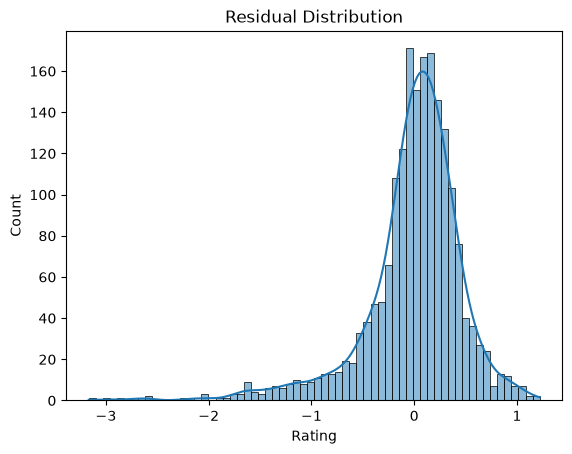

In [49]:
sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")
plt.show()

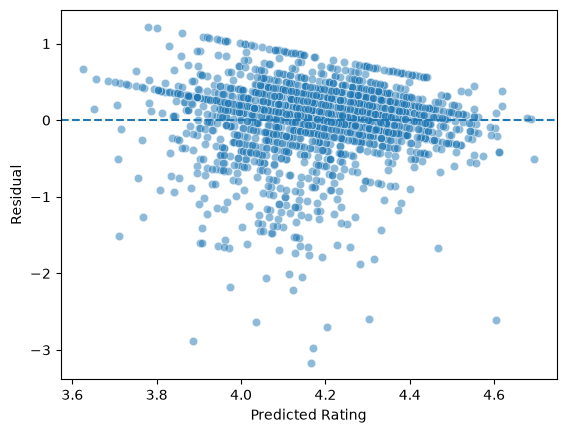

In [50]:
sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Rating")
plt.ylabel("Residual")

plt.show()

In [51]:
# Feature scaling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [52]:
# creating a pipeline 
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [53]:
# define X and Y
X = model_df[
    [
        "log_reviews",
        "log_installs",
        "Size",
        "Price",
        "Type",
        "Category"
    ]
]

y = model_df["Rating"]


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
# train
model_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['log_reviews','log_installs','Size','Price','Type','Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concate

In [56]:
# predict
y_pred = model_pipeline.predict(
    X_test
)

In [57]:
# let's do the evaluation
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.32747445284846277
RMSE: 0.48189968407291733
R²: 0.0833537107582707


In [58]:
# detecting multicolinearity
df[
    ["log_reviews", "log_installs", "Size", "Price"]
].corr()

,log_reviews,log_installs,Size,Price
log_reviews,1.000000,0.958784,0.258204,-0.036981
log_installs,0.958784,1.000000,0.226441,-0.056123
Size,0.258204,0.226441,1.000000,-0.019476
Price,-0.036981,-0.056123,-0.019476,1.000000


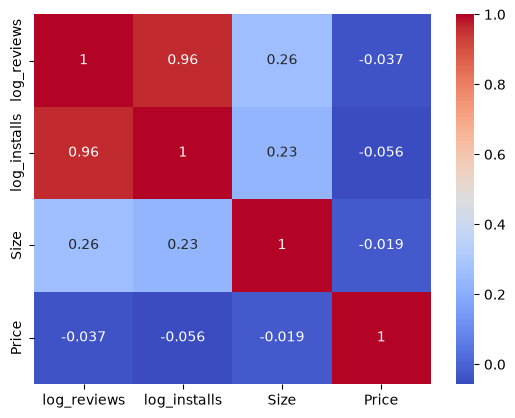

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df[
        ["log_reviews", "log_installs", "Size", "Price"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [60]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [61]:
X_vif = df[
    ["log_reviews", "log_installs", "Size", "Price"]
].dropna()

In [62]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,log_reviews,12.713048
1,log_installs,12.528413
2,Size,1.078087
3,Price,1.006960
